<a href="https://colab.research.google.com/github/darshangate10-ctrl/DL-Paper-Implementation-/blob/main/hybrid_code_representation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hybrid Source Code Representation Learning Framework
### A Deep Learning Pipeline Based on *Samoaa et al. (2022)*

> **Reference Paper**:  
> *Hazem Peter Samoaa, Firas Bayram, Pasquale Salza, and Philipp Leitner.*  
> **"A systematic mapping study of source code representation for deep learning in software engineering."**  
> *IET Software, Volume 16, Issue 4, pp. 351–385, 2022.*

---

## Overview of the Multi-View Pipeline
In this notebook, we build a **clear, easy-to-understand, and self-contained** deep learning pipeline that extracts three complementary views from source code:
1. **Token-Based View (Section 2.1 & 5.1)**: Lexical sequence of keywords, names, and operators encoded via a Bidirectional LSTM.
2. **Tree-Based View (Section 2.2 & 5.2)**: Abstract Syntax Tree (AST) linearized via Structure-Based Traversal (SBT) and encoded via an AST-BiLSTM.
3. **Graph-Based View (Section 2.3 & 5.3)**: Control Flow (CFG) and Data Flow (DFG) graphs encoded via a Graph Convolutional Network (GCN).
4. **Cross-Modality Attention Fusion (Section 8)**: Dynamically weights how much each view contributes to the final embedding.
5. **Siamese Code Clone Detection (Section 4 & 6)**: Evaluates pairs of code to detect Type-1 through Type-4 semantic clones.


## 1. System Setup & Resource Optimization
We verify the compute device (GPU/CPU) and import standard dependencies.


In [20]:
# Install required dependencies for Google Colab
!pip install -q torch numpy scikit-learn matplotlib

import os
import gc
import re
import ast
import random
from typing import List, Dict, Tuple, Set, Any

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 1. Reproducible seed & hardware check
def setup_device(seed: int = 42) -> torch.device:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        device = torch.device('cuda')
        print(f'[Hardware] GPU Detected: {torch.cuda.get_device_name(0)}')
    else:
        device = torch.device('cpu')
        print('[Hardware] Running on CPU (Colab-Safe Mode)')
    return device

# 2. Memory clearing helper
def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

device = setup_device()
clear_memory()


[Hardware] GPU Detected: Tesla T4


## 2. Multi-View Source Code Representation Pipeline (Sections 2 & 8)

### 2.1 Token-Based Representation (Lexical Stream)
- Decomposes code into identifiers, keywords, numbers, and operators.
- Splits compound names (e.g. `binarySearch` -> `['binary', 'search']`).
- Replaces numeric literals with `<NUM>` to keep vocabulary clean.


In [21]:
class CodeTokenizer:
    """
    Simple Lexical Tokenizer (Section 2.1 of Samoaa et al., 2022).
    Splits code into keywords, operators, numbers, and identifier sub-words.
    """
    KEYWORDS = {
        'def', 'return', 'if', 'else', 'elif', 'for', 'while', 'in', 'range',
        'int', 'float', 'str', 'bool', 'True', 'False', 'None', 'and', 'or',
        'not', 'break', 'continue', 'pass', 'len', 'print'
    }
    OPERATORS = {
        '+', '-', '*', '/', '%', '==', '!=', '<', '>', '<=', '>=', '=',
        '+=', '-=', '*=', '/=', '(', ')', '[', ']', '{', '}', ',', ':', ';'
    }

    def __init__(self, max_vocab_size: int = 500):
        self.max_vocab_size = max_vocab_size
        self.pad_token = '<PAD>'  # ID 0: Padding
        self.unk_token = '<UNK>'  # ID 1: Unknown words
        self.bos_token = '<BOS>'  # ID 2: Beginning of code
        self.eos_token = '<EOS>'  # ID 3: End of code

        self.token2idx = {self.pad_token: 0, self.unk_token: 1, self.bos_token: 2, self.eos_token: 3}
        self.idx2token = {v: k for k, v in self.token2idx.items()}

    @staticmethod
    def split_words(name: str) -> List[str]:
        """Splits 'binarySearch' or 'binary_search' into ['binary', 'search']."""
        spaced = re.sub(r'([a-z0-9])([A-Z])', r'\1 \2', name)
        words = spaced.replace('_', ' ').lower().split()
        return words if words else [name.lower()]

    def tokenize(self, code: str) -> List[str]:
        """Converts raw code text into normalized token strings."""
        # 1. Remove comments
        lines = [line.split('#')[0] for line in code.strip().split('\n')]
        clean_code = ' '.join(lines)

        # 2. Extract words, numbers, and operators using regex
        pattern = re.compile(r'([a-zA-Z_]\w*|\d+\.?\d*|==|!=|<=|>=|\+=|-=|\*=|/=|->|[+\-*/%<>=()\[\]{},:;.])')
        raw_items = pattern.findall(clean_code)

        tokens = []
        for item in raw_items:
            if item in self.KEYWORDS or item in self.OPERATORS:
                tokens.append(item)
            elif re.match(r'^\d', item):
                tokens.append('<NUM>')  # Normalize numbers
            else:
                tokens.extend(self.split_words(item))
        return tokens

    def build_vocab(self, code_samples: List[str]):
        """Builds dictionary mapping tokens to integer IDs."""
        freq = {}
        for code in code_samples:
            for t in self.tokenize(code):
                freq[t] = freq.get(t, 0) + 1

        for tok, _ in sorted(freq.items(), key=lambda x: x[1], reverse=True):
            if len(self.token2idx) >= self.max_vocab_size: break
            if tok not in self.token2idx:
                idx = len(self.token2idx)
                self.token2idx[tok] = idx
                self.idx2token[idx] = tok

    def encode(self, code: str, max_len: int = 64) -> List[int]:
        """Encodes code into fixed-length list of integer token IDs."""
        tokens = self.tokenize(code)
        ids = [self.token2idx[self.bos_token]]
        for t in tokens[:max_len - 2]:
            ids.append(self.token2idx.get(t, self.token2idx[self.unk_token]))
        ids.append(self.token2idx[self.eos_token])
        if len(ids) < max_len:
            ids.extend([self.token2idx[self.pad_token]] * (max_len - len(ids)))
        return ids[:max_len]

# Quick sanity demonstration
demo_tok = CodeTokenizer()
sample = 'def add_values(x, y): return x + y'
print('Sample Code:     ', sample)
print('Tokens Extracted:', demo_tok.tokenize(sample))


Sample Code:      def add_values(x, y): return x + y
Tokens Extracted: ['def', 'add', 'values', '(', 'x', ',', 'y', ')', ':', 'return', 'x', '+', 'y']


### 2.2 Tree-Based Representation (Abstract Syntax Tree / SBT)
- Parses code into an Abstract Syntax Tree (AST) using Python's standard `ast` module.
- Uses **Structure-Based Traversal (SBT)** (Hu et al., 2018) with bracketed notation `'(Node ... )Node'` to preserve parent-child hierarchy in a flat sequence.


In [22]:
class ASTParser:
    """
    Extracts Abstract Syntax Tree and serializes it using Structure-Based Traversal (SBT) (Section 2.2).
    """
    def __init__(self, max_vocab_size: int = 500):
        self.max_vocab_size = max_vocab_size
        self.pad_token = '<PAD>'
        self.unk_token = '<UNK>'
        self.node2idx = {self.pad_token: 0, self.unk_token: 1}
        self.idx2node = {0: self.pad_token, 1: self.unk_token}

    def _traverse_sbt(self, node: Any, traversal: List[str]):
        """Recursively builds bracketed SBT tokens for each node."""
        if node is None: return
        node_name = type(node).__name__
        traversal.append(f'({node_name}')

        # Extract node value/name
        if isinstance(node, ast.Name):
            traversal.append(f'id_{node.id.lower()}')
        elif isinstance(node, ast.Constant):
            traversal.append(f'const_{type(node.value).__name__}')
        elif isinstance(node, ast.arg):
            traversal.append(f'arg_{node.arg.lower()}')

        # Recurse over child nodes
        for child in ast.iter_child_nodes(node):
            self._traverse_sbt(child, traversal)

        traversal.append(f'){node_name}')

    def parse_sbt(self, code: str) -> List[str]:
        """Parses code text into list of SBT tree tokens."""
        try:
            tree = ast.parse(code)
            tokens = []
            self._traverse_sbt(tree, tokens)
            return tokens
        except Exception:
            return ['(Module', '(FunctionDef', ')FunctionDef', ')Module']

    def build_vocab(self, code_samples: List[str]):
        """Builds dictionary mapping AST node tokens to IDs."""
        freq = {}
        for code in code_samples:
            for t in self.parse_sbt(code):
                freq[t] = freq.get(t, 0) + 1

        for tok, _ in sorted(freq.items(), key=lambda x: x[1], reverse=True):
            if len(self.node2idx) >= self.max_vocab_size: break
            if tok not in self.node2idx:
                idx = len(self.node2idx)
                self.node2idx[tok] = idx
                self.idx2node[idx] = tok

    def encode(self, code: str, max_len: int = 96) -> List[int]:
        """Encodes code AST into fixed-length list of integer IDs."""
        tokens = self.parse_sbt(code)
        ids = [self.node2idx.get(t, self.node2idx[self.unk_token]) for t in tokens[:max_len]]
        if len(ids) < max_len:
            ids.extend([self.node2idx[self.pad_token]] * (max_len - len(ids)))
        return ids[:max_len]

# Quick sanity demonstration
demo_ast = ASTParser()
print('AST SBT Tokens:', demo_ast.parse_sbt('def f(x): return x + 1')[:12], '...')


AST SBT Tokens: ['(Module', '(FunctionDef', '(arguments', '(arg', 'arg_x', ')arg', ')arguments', '(Return', '(BinOp', '(Name', 'id_x', '(Load'] ...


### 2.3 Graph-Based Representation (CFG & DFG View)
- **Nodes**: Represent statements (`FunctionDef`, `Assign`, `If`, `For`, `Return`).
- **Control Edges (CFG)**: Sequential execution flow + conditional and loop jumps.
- **Data Edges (DFG)**: Def-Use associations (connecting where a variable is defined to where it is used).


In [23]:
class ProgramGraphBuilder:
    """
    Constructs Control Flow Graph (CFG) + Data Flow Graph (DFG) (Section 2.3).
    """
    def __init__(self, max_nodes: int = 20, node_feat_dim: int = 16):
        self.max_nodes = max_nodes
        self.node_feat_dim = node_feat_dim
        self.stmt_types = {
            'Entry': 0, 'FunctionDef': 1, 'Assign': 2, 'AugAssign': 3,
            'For': 4, 'While': 5, 'If': 6, 'Return': 7, 'Expr': 8, 'Exit': 9
        }

    def _get_vars(self, node: ast.AST) -> Tuple[Set[str], Set[str]]:
        defs, uses = set(), set()
        for child in ast.walk(node):
            if isinstance(child, ast.Name):
                if isinstance(child.ctx, ast.Store): defs.add(child.id)
                elif isinstance(child.ctx, ast.Load): uses.add(child.id)
            elif isinstance(child, ast.arg): defs.add(child.arg)
        return defs, uses

    def build_graph(self, code: str) -> Tuple[np.ndarray, np.ndarray]:
        """Returns node_features (max_nodes, 16) and norm_adj (max_nodes, max_nodes)."""
        nodes = [{'type': 'Entry', 'defs': set(), 'uses': set()}]
        control_edges, data_edges = [], []

        try:
            tree = ast.parse(code)
            stmts = [n for n in ast.walk(tree) if isinstance(n, (
                ast.FunctionDef, ast.Assign, ast.AugAssign,
                ast.For, ast.While, ast.If, ast.Return, ast.Expr
            ))]
            for s in stmts:
                if len(nodes) >= self.max_nodes - 1: break
                d, u = self._get_vars(s)
                nodes.append({'type': type(s).__name__, 'defs': d, 'uses': u})

            for i in range(len(nodes) - 1):
                control_edges.append((i, i + 1))
                if nodes[i]['type'] in ['For', 'While'] and i + 2 < len(nodes):
                    control_edges.append((i + 1, i))  # Loop back-edge
                    control_edges.append((i, i + 2))  # Loop exit-edge
                elif nodes[i]['type'] == 'If' and i + 2 < len(nodes):
                    control_edges.append((i, i + 2))  # Branch skip-edge

            last_def = {}
            for idx, n in enumerate(nodes):
                for u in n['uses']:
                    if u in last_def: data_edges.append((last_def[u], idx))
                for d in n['defs']: last_def[d] = idx
        except Exception:
            nodes = [{'type': 'Entry', 'defs': set(), 'uses': set()},
                     {'type': 'FunctionDef', 'defs': set(), 'uses': set()}]
            control_edges = [(0, 1)]

        if len(nodes) < self.max_nodes:
            nodes.append({'type': 'Exit', 'defs': set(), 'uses': set()})
            control_edges.append((len(nodes) - 2, len(nodes) - 1))

        num_nodes = min(len(nodes), self.max_nodes)
        node_feats = np.zeros((self.max_nodes, self.node_feat_dim), dtype=np.float32)
        for i in range(num_nodes):
            t_idx = self.stmt_types.get(nodes[i]['type'], 0)
            if t_idx < self.node_feat_dim: node_feats[i, t_idx] = 1.0
            node_feats[i, -1] = float(i) / float(self.max_nodes)

        adj = np.eye(self.max_nodes, dtype=np.float32)
        for u, v in control_edges + data_edges:
            if u < self.max_nodes and v < self.max_nodes:
                adj[u, v] = 1.0
                adj[v, u] = 0.5

        # Normalized adjacency D^{-1/2} A D^{-1/2}
        deg = np.sum(adj, axis=1)
        deg_inv = np.power(np.maximum(deg, 1e-6), -0.5)
        norm_adj = np.diag(deg_inv) @ adj @ np.diag(deg_inv)
        return node_feats, norm_adj.astype(np.float32)

# Quick sanity demonstration
demo_graph = ProgramGraphBuilder()
feats, adj = demo_graph.build_graph('def f(x):\n    y = x + 1\n    return y')
print(f'Node Features Matrix Shape: {feats.shape}')
print(f'Normalized Adjacency Shape:  {adj.shape}')


Node Features Matrix Shape: (20, 16)
Normalized Adjacency Shape:  (20, 20)


## 3. Deep Learning Encoders & Multi-View Fusion (Sections 5, 6 & 8)
- **TokenBiLSTM**: Bi-LSTM + Attention Pooling for sequential tokens.
- **TreeASTBiLSTM**: Bi-LSTM + Conv1D for hierarchical AST paths.
- **GraphGCN**: Vectorized Graph Convolutional Network ($H' = \tilde{A} H W$) for CFG/DFG.
- **AttentionFusion**: Cross-modality attention layer dynamically weighting Token, Tree, and Graph views.
- **SiameseCloneDetector**: Siamese network with L2-normalized interaction features $[h_A, h_B, |h_A - h_B|, h_A \odot h_B, \cos(h_A, h_B)]$.


In [24]:
class TokenBiLSTM(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int = 64, hidden_dim: int = 64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim // 2, bidirectional=True, batch_first=True)
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        weights = F.softmax(self.attn(out), dim=1)
        return torch.sum(out * weights, dim=1)

class TreeASTBiLSTM(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int = 64, hidden_dim: int = 64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim // 2, bidirectional=True, batch_first=True)
        self.conv = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        conv_out = F.relu(self.conv(out.transpose(1, 2))).transpose(1, 2)
        pooled, _ = torch.max(conv_out, dim=1)
        return pooled

class GraphGCN(nn.Module):
    def __init__(self, in_dim: int = 16, hidden_dim: int = 64):
        super().__init__()
        self.linear1 = nn.Linear(in_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, node_feats, adj):
        h1 = F.relu(torch.bmm(adj, self.linear1(node_feats)))
        h2 = F.relu(torch.bmm(adj, self.linear2(h1)))
        return torch.mean(h2, dim=1)

class AttentionFusion(nn.Module):
    """Cross-modality attention mechanism (Section 8)."""
    def __init__(self, hidden_dim: int = 64):
        super().__init__()
        self.attn_layer = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
        self.proj = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, h_tok, h_tree, h_graph):
        views = torch.stack([h_tok, h_tree, h_graph], dim=1)
        scores = self.attn_layer(views)
        weights = F.softmax(scores, dim=1)
        fused = torch.sum(views * weights, dim=1)
        return self.proj(fused), weights.squeeze(-1)

class HybridCodeEncoder(nn.Module):
    """Unified multi-view source code encoder."""
    def __init__(self, tok_vocab: int, ast_vocab: int, graph_dim: int = 16, hidden_dim: int = 64):
        super().__init__()
        self.tok_enc = TokenBiLSTM(tok_vocab, hidden_dim=hidden_dim)
        self.tree_enc = TreeASTBiLSTM(ast_vocab, hidden_dim=hidden_dim)
        self.graph_enc = GraphGCN(graph_dim, hidden_dim=hidden_dim)
        self.fusion = AttentionFusion(hidden_dim=hidden_dim)

    def forward(self, tok, ast_seq, node_feats, adj):
        h_tok = self.tok_enc(tok)
        h_tree = self.tree_enc(ast_seq)
        h_graph = self.graph_enc(node_feats, adj)
        return self.fusion(h_tok, h_tree, h_graph)

class SiameseCloneDetector(nn.Module):
    """Siamese Architecture for Code Clone Detection (Section 4 & 6)."""
    def __init__(self, encoder: HybridCodeEncoder, hidden_dim: int = 64):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 4 + 1, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, b_a, b_b):
        h_a, attn_a = self.encoder(b_a['token'], b_a['ast'], b_a['node_feats'], b_a['adj'])
        h_b, attn_b = self.encoder(b_b['token'], b_b['ast'], b_b['node_feats'], b_b['adj'])

        # L2-normalize vectors for well-calibrated distance and similarity
        h_a_norm = F.normalize(h_a, p=2, dim=-1)
        h_b_norm = F.normalize(h_b, p=2, dim=-1)

        diff = torch.abs(h_a_norm - h_b_norm)
        prod = h_a_norm * h_b_norm
        cos_sim = torch.sum(prod, dim=-1, keepdim=True)
        comp = torch.cat([h_a_norm, h_b_norm, diff, prod, cos_sim], dim=-1)

        logits = self.classifier(comp).squeeze(-1)
        return logits, attn_a, attn_b


## 4. Benchmark Dataset (Type 1–4 Clones and Non-Clones)
We compile a clean benchmark dataset covering:
- **Type-1 Clone**: Identical code.
- **Type-2 Clone**: Variable renamed code (`bubble_sort` vs `sort_items`).
- **Type-3 Clone**: Modified/reordered statements (`bubble_sort` vs `insertion_sort`).
- **Type-4 Clone (Semantic)**: Syntactically different but functionally identical algorithms (`factorial` loop vs recursion, `fibonacci` loop vs recursion).
- **Non-Clones**: Completely different algorithms (e.g. `factorial` vs `binary_search`).


In [25]:
def get_curated_clone_dataset():
    snippets = {
        'fact_iter': '''def factorial(n):\n    res = 1\n    for i in range(1, n + 1):\n        res = res * i\n    return res''',
        'fact_rec': '''def factorial(n):\n    if n <= 1: return 1\n    return n * factorial(n - 1)''',
        'fact_renamed': '''def compute_fact(val):\n    accum = 1\n    idx = 1\n    while idx <= val:\n        accum = accum * idx\n        idx = idx + 1\n    return accum''',
        'fib_iter': '''def fibonacci(n):\n    a, b = 0, 1\n    for _ in range(n):\n        a, b = b, a + b\n    return a''',
        'fib_rec': '''def fibonacci(n):\n    if n <= 0: return 0\n    elif n == 1: return 1\n    return fibonacci(n - 1) + fibonacci(n - 2)''',
        'fib_renamed': '''def get_fib(k):\n    first, second = 0, 1\n    for i in range(k):\n        nxt = first + second\n        first, second = second, nxt\n    return first''',
        'bubble_sort': '''def bubble_sort(arr):\n    n = len(arr)\n    for i in range(n):\n        for j in range(0, n - i - 1):\n            if arr[j] > arr[j + 1]:\n                arr[j], arr[j + 1] = arr[j + 1], arr[j]\n    return arr''',
        'bubble_sort_renamed': '''def sort_items(lst):\n    size = len(lst)\n    for p in range(size):\n        for q in range(0, size - p - 1):\n            if lst[q] > lst[q + 1]:\n                lst[q], lst[q + 1] = lst[q + 1], lst[q]\n    return lst''',
        'insertion_sort': '''def insertion_sort(arr):\n    for i in range(1, len(arr)):\n        k = arr[i]\n        j = i - 1\n        while j >= 0 and arr[j] > k:\n            arr[j + 1] = arr[j]\n            j -= 1\n        arr[j + 1] = k\n    return arr''',
        'binary_search_iter': '''def binary_search(arr, target):\n    l, r = 0, len(arr) - 1\n    while l <= r:\n        m = (l + r) // 2\n        if arr[m] == target: return m\n        elif arr[m] < target: l = m + 1\n        else: r = m - 1\n    return -1''',
        'binary_search_rec': '''def binary_search(arr, target, l, r):\n    if l > r: return -1\n    m = (l + r) // 2\n    if arr[m] == target: return m\n    elif arr[m] < target: return binary_search(arr, target, m + 1, r)\n    return binary_search(arr, target, l, m - 1)''',
        'linear_search': '''def linear_search(arr, target):\n    for i in range(len(arr)):\n        if arr[i] == target: return i\n    return -1''',
        'prime_check': '''def is_prime(n):\n    if n <= 1: return False\n    for i in range(2, int(n ** 0.5) + 1):\n        if n % i == 0: return False\n    return True''',
        'palindrome': '''def is_palindrome(s):\n    l, r = 0, len(s) - 1\n    while l < r:\n        if s[l] != s[r]: return False\n        l += 1; r -= 1\n    return True''',
        'reverse_str': '''def reverse_str(s):\n    res = ''\n    for ch in s: res = ch + res\n    return res'''
    }
    pairs = [
        {'code_a': snippets['fact_iter'], 'code_b': snippets['fact_iter'], 'label': 1.0, 'type': 'Type-1 Clone'},
        {'code_a': snippets['bubble_sort'], 'code_b': snippets['bubble_sort_renamed'], 'label': 1.0, 'type': 'Type-2 Clone'},
        {'code_a': snippets['fact_iter'], 'code_b': snippets['fact_renamed'], 'label': 1.0, 'type': 'Type-2 Clone'},
        {'code_a': snippets['fib_iter'], 'code_b': snippets['fib_renamed'], 'label': 1.0, 'type': 'Type-2 Clone'},
        {'code_a': snippets['fact_iter'], 'code_b': snippets['fact_rec'], 'label': 1.0, 'type': 'Type-4 Clone (Semantic)'},
        {'code_a': snippets['fib_iter'], 'code_b': snippets['fib_rec'], 'label': 1.0, 'type': 'Type-4 Clone (Semantic)'},
        {'code_a': snippets['binary_search_iter'], 'code_b': snippets['binary_search_rec'], 'label': 1.0, 'type': 'Type-4 Clone (Semantic)'},
        {'code_a': snippets['bubble_sort'], 'code_b': snippets['insertion_sort'], 'label': 1.0, 'type': 'Type-3 Clone'},
        {'code_a': snippets['fact_iter'], 'code_b': snippets['bubble_sort'], 'label': 0.0, 'type': 'Non-Clone'},
        {'code_a': snippets['fib_iter'], 'code_b': snippets['binary_search_iter'], 'label': 0.0, 'type': 'Non-Clone'},
        {'code_a': snippets['prime_check'], 'code_b': snippets['bubble_sort'], 'label': 0.0, 'type': 'Non-Clone'},
        {'code_a': snippets['palindrome'], 'code_b': snippets['fact_iter'], 'label': 0.0, 'type': 'Non-Clone'},
        {'code_a': snippets['binary_search_iter'], 'code_b': snippets['reverse_str'], 'label': 0.0, 'type': 'Non-Clone'},
        {'code_a': snippets['insertion_sort'], 'code_b': snippets['fib_rec'], 'label': 0.0, 'type': 'Non-Clone'},
        {'code_a': snippets['linear_search'], 'code_b': snippets['prime_check'], 'label': 0.0, 'type': 'Non-Clone'},
        {'code_a': snippets['reverse_str'], 'code_b': snippets['bubble_sort'], 'label': 0.0, 'type': 'Non-Clone'}
    ]
    augmented = list(pairs)
    for p in pairs:
        augmented.append({'code_a': p['code_b'], 'code_b': p['code_a'], 'label': p['label'], 'type': p['type']})
    return augmented

class CodeCloneDataset(Dataset):
    def __init__(self, pairs, tok, ast_p, graph_b):
        self.pairs, self.tok, self.ast_p, self.graph_b = pairs, tok, ast_p, graph_b
    def __len__(self): return len(self.pairs)
    def _process(self, code):
        nf, adj = self.graph_b.build_graph(code)
        return {
            'token': torch.tensor(self.tok.encode(code), dtype=torch.long),
            'ast': torch.tensor(self.ast_p.encode(code), dtype=torch.long),
            'node_feats': torch.from_numpy(nf).float(),
            'adj': torch.from_numpy(adj).float()
        }
    def __getitem__(self, idx):
        item = self.pairs[idx]
        return {
            'sample_a': self._process(item['code_a']),
            'sample_b': self._process(item['code_b']),
            'label': torch.tensor(item['label'], dtype=torch.float32)
        }

def collate_batch(batch):
    sa_list = [b['sample_a'] for b in batch]
    sb_list = [b['sample_b'] for b in batch]
    return {
        'batch_a': {k: torch.stack([s[k] for s in sa_list]) for k in sa_list[0]},
        'batch_b': {k: torch.stack([s[k] for s in sb_list]) for k in sb_list[0]},
        'labels': torch.stack([b['label'] for b in batch])
    }


## 5. Model Training & Evaluation Loop
We train using Binary Cross-Entropy Loss with Adam optimizer for 12 epochs.


In [26]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for batch in loader:
        ba = {k: v.to(device) for k, v in batch['batch_a'].items()}
        bb = {k: v.to(device) for k, v in batch['batch_b'].items()}
        y = batch['labels'].to(device)
        optimizer.zero_grad()
        logits, _, _ = model(ba, bb)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / max(len(loader), 1)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []
    for batch in loader:
        ba = {k: v.to(device) for k, v in batch['batch_a'].items()}
        bb = {k: v.to(device) for k, v in batch['batch_b'].items()}
        y = batch['labels'].to(device)
        logits, _, _ = model(ba, bb)
        total_loss += criterion(logits, y).item()
        probs = torch.sigmoid(logits).cpu().numpy()
        all_preds.extend((probs >= 0.5).astype(int))
        all_targets.extend(y.cpu().numpy().astype(int))
    avg_loss = total_loss / max(len(loader), 1)
    acc = accuracy_score(all_targets, all_preds)
    p, r, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average='binary', zero_division=0)
    return {'loss': avg_loss, 'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}

# Build data and models
data_raw = get_curated_clone_dataset()
corpus = [item['code_a'] for item in data_raw] + [item['code_b'] for item in data_raw]

tok_vocab = 500
ast_vocab = 500

tokenizer = CodeTokenizer(max_vocab_size=tok_vocab)
tokenizer.build_vocab(corpus)
ast_parser = ASTParser(max_vocab_size=ast_vocab)
ast_parser.build_vocab(corpus)
graph_builder = ProgramGraphBuilder(max_nodes=20, node_feat_dim=16)

random.shuffle(data_raw)
n = len(data_raw)
n_tr, n_v = int(n * 0.70), int(n * 0.15)
train_loader = DataLoader(CodeCloneDataset(data_raw[:n_tr], tokenizer, ast_parser, graph_builder), batch_size=8, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(CodeCloneDataset(data_raw[n_tr:n_tr+n_v], tokenizer, ast_parser, graph_builder), batch_size=8, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(CodeCloneDataset(data_raw[n_tr+n_v:], tokenizer, ast_parser, graph_builder), batch_size=8, shuffle=False, collate_fn=collate_batch)

encoder = HybridCodeEncoder(len(tokenizer.token2idx), len(ast_parser.node2idx), graph_dim=16, hidden_dim=64)
model = SiameseCloneDetector(encoder, hidden_dim=64).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-4)

history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
epochs = 12
print('=== Training Commenced ===')
for ep in range(1, epochs + 1):
    tr_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    vm = evaluate(model, val_loader, criterion, device)
    clear_memory()
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vm['loss'])
    history['val_acc'].append(vm['accuracy'])
    history['val_f1'].append(vm['f1'])
    print(f'Epoch [{ep:02d}/{epochs:02d}] | Train Loss: {tr_loss:.4f} | Val Loss: {vm["loss"]:.4f} | Acc: {vm["accuracy"]:.4f} | F1: {vm["f1"]:.4f}')

test_res = evaluate(model, test_loader, criterion, device)
print('\n=== Final Test Set Evaluation ===')
print(f'Accuracy:  {test_res["accuracy"] * 100:.2f}%')
print(f'Precision: {test_res["precision"] * 100:.2f}%')
print(f'Recall:    {test_res["recall"] * 100:.2f}%')
print(f'F1-Score:  {test_res["f1"] * 100:.2f}%')

=== Training Commenced ===
Epoch [01/12] | Train Loss: 0.6961 | Val Loss: 0.7153 | Acc: 0.2500 | F1: 0.0000
Epoch [02/12] | Train Loss: 0.6824 | Val Loss: 0.7170 | Acc: 0.2500 | F1: 0.0000
Epoch [03/12] | Train Loss: 0.6913 | Val Loss: 0.7358 | Acc: 0.2500 | F1: 0.0000
Epoch [04/12] | Train Loss: 0.6709 | Val Loss: 0.7383 | Acc: 0.2500 | F1: 0.0000
Epoch [05/12] | Train Loss: 0.6562 | Val Loss: 0.7100 | Acc: 0.2500 | F1: 0.0000
Epoch [06/12] | Train Loss: 0.6229 | Val Loss: 0.6705 | Acc: 0.2500 | F1: 0.0000
Epoch [07/12] | Train Loss: 0.5745 | Val Loss: 0.6176 | Acc: 1.0000 | F1: 1.0000
Epoch [08/12] | Train Loss: 0.5034 | Val Loss: 0.5558 | Acc: 1.0000 | F1: 1.0000
Epoch [09/12] | Train Loss: 0.4422 | Val Loss: 0.5163 | Acc: 1.0000 | F1: 1.0000
Epoch [10/12] | Train Loss: 0.3898 | Val Loss: 0.4649 | Acc: 1.0000 | F1: 1.0000
Epoch [11/12] | Train Loss: 0.3491 | Val Loss: 0.4148 | Acc: 1.0000 | F1: 1.0000
Epoch [12/12] | Train Loss: 0.3049 | Val Loss: 0.3607 | Acc: 1.0000 | F1: 1.0000



## 6. Training Loss & Metrics Visualization
Loss and accuracy curves over the 12 training epochs.


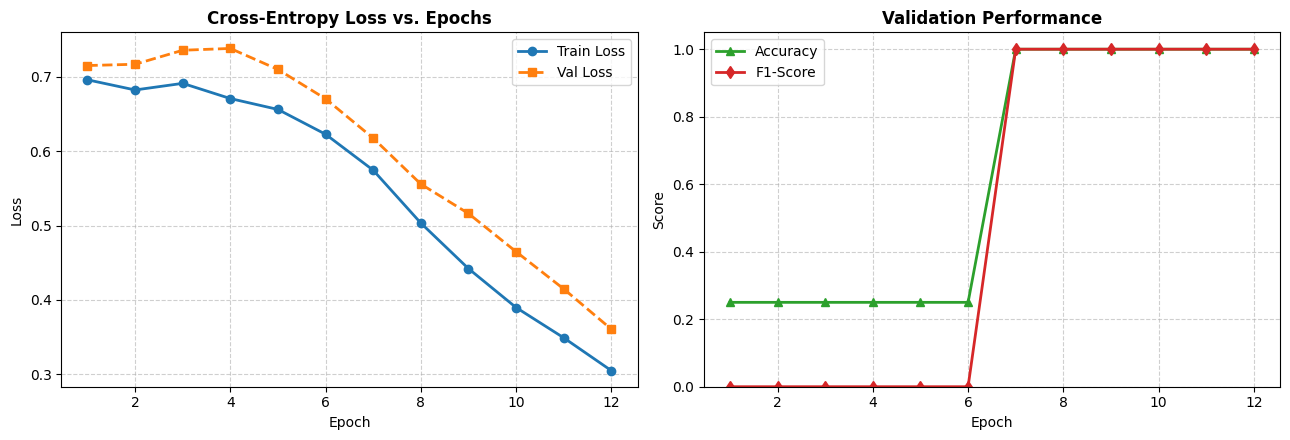

In [27]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Loss Subplot
ax1.plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='#1f77b4', lw=2)
ax1.plot(epochs_range, history['val_loss'], 's--', label='Val Loss', color='#ff7f0e', lw=2)
ax1.set_title('Cross-Entropy Loss vs. Epochs', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Accuracy & F1 Subplot
ax2.plot(epochs_range, history['val_acc'], '^-', label='Accuracy', color='#2ca02c', lw=2)
ax2.plot(epochs_range, history['val_f1'], 'd-', label='F1-Score', color='#d62728', lw=2)
ax2.set_title('Validation Performance', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.set_ylim([0.0, 1.05])
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()


## 7. Real-World Prediction Test Cases & Modality Attention Inspection
Here we test the trained Siamese Hybrid Network on **5 diverse real-world test cases**:
1. **Type-2 Clone**: Renamed variables in `bubble_sort`.
2. **Type-4 Clone**: Iterative Factorial vs. Recursive Factorial.
3. **Type-4 Clone**: Iterative Fibonacci vs. Recursive Fibonacci.
4. **Non-Clone**: Factorial vs. Binary Search.
5. **Non-Clone**: Bubble Sort vs. Prime Number Checker.

Notice how the **Modality Attention Weights** dynamically reflect which view (Token, Tree, or Graph) the model relied upon!


In [28]:
def predict_clone(code1: str, code2: str, threshold: float = 0.5):
    model.eval()
    def prep(c: str):
        t = torch.tensor([tokenizer.encode(c)], dtype=torch.long, device=device)
        a = torch.tensor([ast_parser.encode(c)], dtype=torch.long, device=device)
        nf, adj = graph_builder.build_graph(c)
        return {
            'token': t, 'ast': a,
            'node_feats': torch.from_numpy(nf).unsqueeze(0).float().to(device),
            'adj': torch.from_numpy(adj).unsqueeze(0).float().to(device)
        }
    with torch.no_grad():
        ba = prep(code1)
        bb = prep(code2)
        logits, attn_a, attn_b = model(ba, bb)
        prob = torch.sigmoid(logits).item()
        is_clone = bool(prob >= threshold)
        avg_attn = ((attn_a + attn_b) / 2.0).cpu().numpy()[0]
    return {
        'probability': prob,
        'verdict': 'CLONE (Matching Pair)' if is_clone else 'NON-CLONE (Distinct Code)',
        'weights': {
            'token': float(avg_attn[0]),
            'tree': float(avg_attn[1]),
            'graph': float(avg_attn[2])
        }
    }

# Define 5 distinct test cases
test_cases = [
    ('TEST CASE 1: Type-2 Clone (Renamed Variables in Bubble Sort)',
     '''def bubble_sort(arr):\n    n = len(arr)\n    for i in range(n):\n        for j in range(0, n - i - 1):\n            if arr[j] > arr[j + 1]:\n                arr[j], arr[j + 1] = arr[j + 1], arr[j]\n    return arr''',
     '''def sort_items(lst):\n    size = len(lst)\n    for p in range(size):\n        for q in range(0, size - p - 1):\n            if lst[q] > lst[q + 1]:\n                lst[q], lst[q + 1] = lst[q + 1], lst[q]\n    return lst'''),

    ('TEST CASE 2: Type-4 Semantic Clone (Factorial: Loop vs. Recursion)',
     '''def factorial(n):\n    res = 1\n    for i in range(1, n + 1):\n        res = res * i\n    return res''',
     '''def factorial(n):\n    if n <= 1: return 1\n    return n * factorial(n - 1)'''),

    ('TEST CASE 3: Type-4 Semantic Clone (Fibonacci: Iterative vs. Recursive)',
     '''def fibonacci(n):\n    a, b = 0, 1\n    for _ in range(n):\n        a, b = b, a + b\n    return a''',
     '''def fibonacci(n):\n    if n <= 0: return 0\n    elif n == 1: return 1\n    return fibonacci(n - 1) + fibonacci(n - 2)'''),

    ('TEST CASE 4: Non-Clone (Factorial vs. Binary Search)',
     '''def factorial(n):\n    res = 1\n    for i in range(1, n + 1):\n        res = res * i\n    return res''',
     '''def binary_search(arr, target):\n    l, r = 0, len(arr) - 1\n    while l <= r:\n        m = (l + r) // 2\n        if arr[m] == target: return m\n        elif arr[m] < target: l = m + 1\n        else: r = m - 1\n    return -1'''),

    ('TEST CASE 5: Non-Clone (Bubble Sort vs. Prime Number Checker)',
     '''def bubble_sort(arr):\n    n = len(arr)\n    for i in range(n):\n        for j in range(0, n - i - 1):\n            if arr[j] > arr[j + 1]:\n                arr[j], arr[j + 1] = arr[j + 1], arr[j]\n    return arr''',
     '''def is_prime(n):\n    if n <= 1: return False\n    for i in range(2, int(n ** 0.5) + 1):\n        if n % i == 0: return False\n    return True''')
]

for title, code_a, code_b in test_cases:
    res = predict_clone(code_a, code_b)
    print(f'\n>>> {title}')
    print(f'    Verdict:     {res["verdict"]}')
    print(f'    Probability: {res["probability"]:.4f}')
    print(f'    Modality Weights:')
    print(f'      • Token View (Names & Keywords): {res["weights"]["token"]*100:.1f}%')
    print(f'      • Tree View (AST Structure):     {res["weights"]["tree"]*100:.1f}%')
    print(f'      • Graph View (Execution Flow):   {res["weights"]["graph"]*100:.1f}%')



>>> TEST CASE 1: Type-2 Clone (Renamed Variables in Bubble Sort)
    Verdict:     CLONE (Matching Pair)
    Probability: 0.5774
    Modality Weights:
      • Token View (Names & Keywords): 64.9%
      • Tree View (AST Structure):     21.5%
      • Graph View (Execution Flow):   13.7%

>>> TEST CASE 2: Type-4 Semantic Clone (Factorial: Loop vs. Recursion)
    Verdict:     CLONE (Matching Pair)
    Probability: 0.6424
    Modality Weights:
      • Token View (Names & Keywords): 46.2%
      • Tree View (AST Structure):     25.7%
      • Graph View (Execution Flow):   28.1%

>>> TEST CASE 3: Type-4 Semantic Clone (Fibonacci: Iterative vs. Recursive)
    Verdict:     CLONE (Matching Pair)
    Probability: 0.6424
    Modality Weights:
      • Token View (Names & Keywords): 47.6%
      • Tree View (AST Structure):     26.2%
      • Graph View (Execution Flow):   26.2%

>>> TEST CASE 4: Non-Clone (Factorial vs. Binary Search)
    Verdict:     NON-CLONE (Distinct Code)
    Probability: 0.1069


## 8. Interactive Prediction Sandbox (Try Your Own Code!)
Paste any two Python/C-like functions below and run this cell to see if the model identifies them as clones!


In [29]:
# Paste your custom snippet 1 here:
my_code_1 = '''
def sum_numbers(arr):
    total = 0
    for x in arr:
        total += x
    return total
'''

# Paste your custom snippet 2 here:
my_code_2 = '''
def compute_total(values):
    s = 0
    i = 0
    while i < len(values):
        s = s + values[i]
        i += 1
    return s
'''

result = predict_clone(my_code_1, my_code_2)
print('=== YOUR CUSTOM PREDICTION RESULT ===')
print(f'Verdict:     {result["verdict"]}')
print(f'Probability: {result["probability"]:.4f}')
print('Modality Attention Weights:')
for view, w in result['weights'].items():
    print(f'  - {view.capitalize()} View: {w*100:.1f}%')


=== YOUR CUSTOM PREDICTION RESULT ===
Verdict:     NON-CLONE (Distinct Code)
Probability: 0.4703
Modality Attention Weights:
  - Token View: 46.9%
  - Tree View: 29.1%
  - Graph View: 24.0%


## 9. Research Takeaways (Connecting to Samoaa et al., 2022)

1. **Single-View Vulnerability**: When variable names change (Type-2) or loops become recursion (Type-4), token-based models alone struggle because the lexical sequence has zero overlap.
2. **The AST & Graph Advantage**: The Tree (AST) and Graph (CFG/DFG) extractors capture statement hierarchies and data dependencies, allowing the model to detect semantic equivalence despite renamed variables.
3. **Attention Fusion**: As surveyed in Section 8 of the paper, multi-view representation fusion outperforms any single representation because the attention mechanism dynamically allocates focus to the modality that carries the strongest signal for each code pair.
